In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

plt.style.use("dark_background")

In [58]:
#Understanding the Data 


df=pd.read_csv("US Airline Flight Routes.csv",low_memory=False)
df_copy = df.copy()
df_copy["passengers"]

0         180
1          19
2         204
3         264
4         398
         ... 
245950    207
245951    277
245952     70
245953    178
245954     57
Name: passengers, Length: 245955, dtype: int64

In [59]:
df_copy[["Year","passengers","fare","fare_low","carrier_lg","fare_lg","carrier_low"]].describe()
df_copy["Year"].sample(5)

211464    2018
175360    1999
148416    2014
69289     2002
185074    2015
Name: Year, dtype: int64

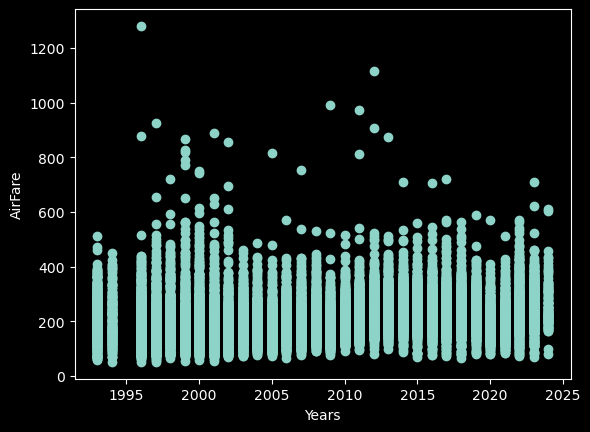

In [131]:
sample_data = df_copy.sample(15000)

plt.scatter(sample_data["Year"],sample_data["fare"])

plt.xlabel("Years")
plt.ylabel("AirFare")
plt.show()

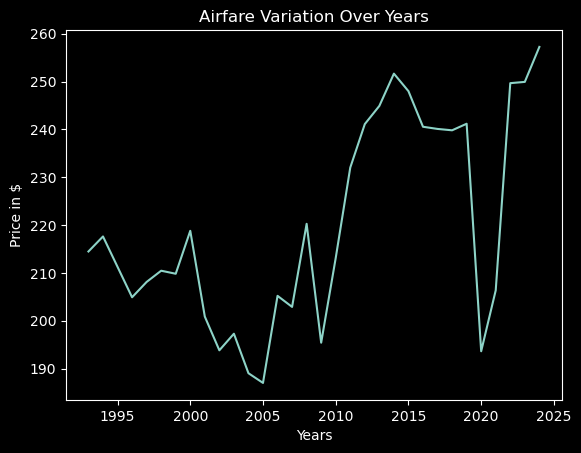

In [61]:
#Airfares changed over years (1995–2025)

avg_fare = df_copy.groupby("Year")["fare"].mean()
plt.plot(avg_fare.index,avg_fare.values)
plt.xlabel("Years")
plt.ylabel("Price in $")
plt.title("Airfare Variation Over Years")
plt.show()

In [ ]:
# Airfare Trend (1993–2024)
Fares rose steadily till 2008, crashed during the financial crisis,
recovered slowly, then spiked post-COVID as demand outpaced capacity.

Key Finding: External shocks impact airfares more than competition.

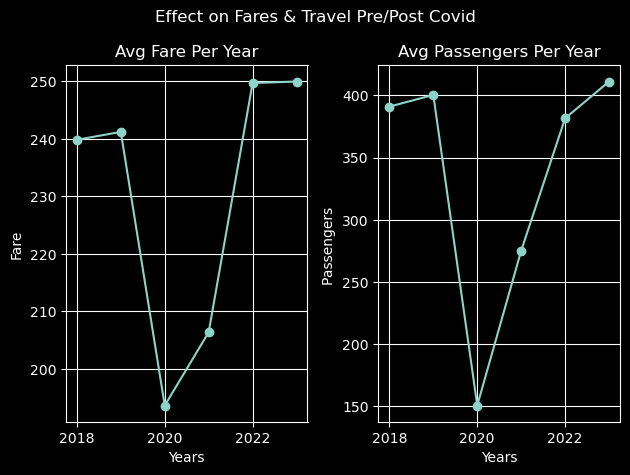

In [127]:
#Analyzes the impact of COVID-19 on airline travel by comparing average fares and passenger counts from 2018–2023.

filtered_data = df_copy[df_copy["Year"].isin([2018,2019,2020,2021,2022,2023])]

avg_pax = filtered_data.groupby("Year")["passengers"].mean()
avg_fare = filtered_data.groupby("Year")["fare"].mean()


fig , ax = plt.subplots(1,2)

ax[0].plot(avg_fare.index , avg_fare.values , marker="o")
ax[0].set_ylabel("Fare")
ax[0].set_xlabel("Years")
ax[0].set_title("Avg Fare Per Year")
ax[0].grid(True)


ax[1].plot(avg_pax.index,avg_pax.values,marker="o")
ax[1].set_ylabel("Passengers ")
ax[1].set_xlabel("Years")
ax[1].set_title("Avg Passengers Per Year")
ax[1].grid(True)

fig.suptitle("Effect on Fares & Travel Pre/Post Covid")
fig.tight_layout()
plt.show()


In [ ]:
##COVID Impact on Aviation (2018–2023)

2020 was catastrophic — passengers collapsed and fares dropped as
airlines desperately tried filling empty seats. Fares spiked in 2022
as demand returned faster than capacity.

Key Finding: COVID hit revenue from both sides — fewer passengers & lower fares simultaneously.

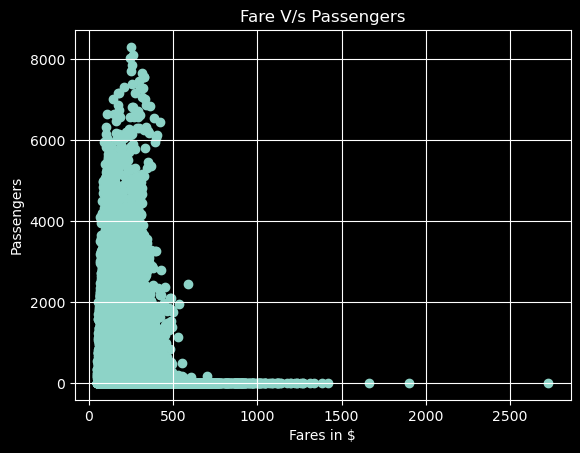

In [132]:
#Do more passengers on a route = lower fare?


plt.scatter(df_copy["fare_low"] , df_copy["passengers"])
plt.xlabel("Fares in $")
plt.ylabel("Passengers")
plt.title("Fare V/s Passengers")
plt.grid(True)

In [128]:
#Top 20 Busy Routes 

top_routes = df_copy.groupby(["airport_1","airport_2"])["passengers"].sum().nlargest(20)
print(top_routes)

#Top Airlines that handles this passenger traffic 

top_airlines =df.groupby(["airport_1","airport_2","large_ms"])["passengers"].sum().nlargest(10)
print(top_airlines)

airport_1  airport_2
LAX        JFK          585728
ORD        LGA          478390
LAX        SFO          444759
JFK        SFO          396627
ATL        LGA          388905
ORD        LAX          359834
EWR        MCO          356760
FLL        LGA          355277
LAX        SEA          335318
LAS        LAX          318512
BOS        LGA          303722
LAX        EWR          301406
FLL        EWR          274474
DEN        LAX          271921
LGA        MCO          270181
BOS        ORD          269659
ORD        EWR          268448
BOS        MCO          268438
ORD        SFO          266151
EWR        SFO          266050
Name: passengers, dtype: int64
airport_1  airport_2  large_ms
DAL        HOU        0.99        171934
BUR        OAK        0.99        165983
HOU        MSY        0.99         89891
DAL        SAT        0.99         77643
SAN        OAK        0.98         72541
BUR        SJC        0.99         71473
ONT        OAK        0.99         63816
MDW       

In [ ]:
#  Busiest US Routes
Top routes are dominated by short-haul city pairs between major
metros like LAX–SFO and JFK–LAX where competition is highest.

Key Finding: High traffic routes concentrate between East and West Coast metro cities.

Text(0.5, 1.0, 'Top 6 Airlines Dominating US Market by Passengers')

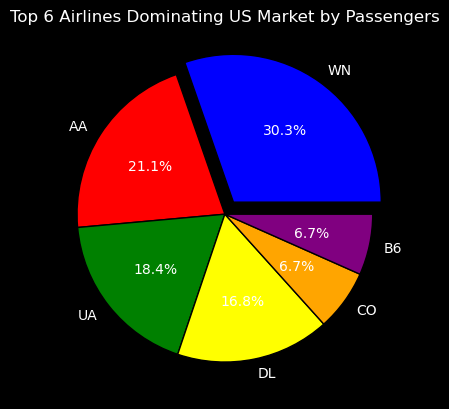

In [129]:
#Dominating Airline over MARKET 

market_share = df_copy.groupby("carrier_lg")["passengers"].sum().nlargest(6)

labels=market_share.index
values=market_share.values
colors = ["blue","red","green","yellow","orange","purple"]
explode=[0.1,0,0,0,0,0]
plt.pie(values , labels = labels , autopct="%1.1f%%",colors=colors , 
       wedgeprops={
           "edgecolor" : "black",
           "linewidth" : 1,
           "linestyle" : "-"
       },
        explode=explode
       )
plt.title("Top 6 Airlines Dominating US Market by Passengers")
